In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ayeshasiddiqa123/finance-trends-2020-2025/Finance_Trends.csv


# RQ4 Feature Importance and Interpretability

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42

In [3]:
file_path = "/kaggle/input/datasets/ayeshasiddiqa123/finance-trends-2020-2025/Finance_Trends.csv"

df_raw = pd.read_csv(file_path)

print("Original shape:", df_raw.shape)

# Clean column names
def clean_column_names(df):
    df = df.copy()

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    return df

# Choose target variable
def choose_target(df):
    possible_targets = [
        "Investment_Avenues",
        "Investment_Preference",
        "investment_avenues",
        "investment_preference",
        "Avenue",
        "Preferred_Investment"
    ]

    for col in possible_targets:
        if col in df.columns:
            return col

    object_cols = df.select_dtypes(include="object").columns.tolist()

    if object_cols:
        return object_cols[-1]

    return df.columns[-1]

# Basic cleaning
def basic_cleaning(df):

    df = clean_column_names(df)

    df = df.drop_duplicates()

    for col in df.columns:

        if df[col].dtype == "object":

            df[col] = df[col].astype(str).str.strip()

            df[col] = df[col].replace("nan", np.nan)

            if df[col].isna().sum() > 0:
                df[col] = df[col].fillna(df[col].mode()[0])

        else:

            df[col] = pd.to_numeric(df[col], errors="coerce")

            df[col] = df[col].fillna(df[col].median())

    return df


Original shape: (12000, 24)


In [4]:
def prepare_numeric_ml_data(df, target_col):

    df_model = df.copy()

    encoders = {}

    for col in df_model.columns:

        if df_model[col].dtype == "object":

            le = LabelEncoder()

            df_model[col] = le.fit_transform(df_model[col].astype(str))

            encoders[col] = le

    X = df_model.drop(columns=[target_col])

    y = df_model[target_col]

    return X, y, encoders

# Evaluate model
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1_Score": f1_score(y_test, pred, average="weighted", zero_division=0)
    }, pred

# Clean dataset
df = basic_cleaning(df_raw)

target_col = choose_target(df)

print("Selected target variable:", target_col)

display(df.head())

X, y, encoders = prepare_numeric_ml_data(df, target_col)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Selected target variable: Investment_Avenues


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What_are_your_savings_objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Male,29,Yes,2,4,7,5,3,1,6,...,Less than 1 year,Weekly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines
1,Male,28,Yes,2,3,6,5,1,4,7,...,Less than 1 year,Weekly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television
2,Female,28,Yes,2,3,7,5,4,1,6,...,3-5 years,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants
3,Male,19,Yes,2,3,7,4,6,1,5,...,More than 5 years,Monthly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
4,Male,32,Yes,2,4,7,5,3,1,6,...,More than 5 years,Weekly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants


Training rows: 8311
Testing rows: 2078


In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(10))

importance_df.to_csv(
    "RQ4_feature_importance.csv",
    index=False
)

top10 = importance_df.head(10)




,Feature,Importance
9,Stock_Marktet,0.194138
2,Mutual_Funds,0.104046
8,Gold,0.100556
4,Debentures,0.086977
21,Reason_FD,0.077684
7,PPF,0.066360
3,Equity_Market,0.065362
5,Government_Bonds,0.047007
22,Source,0.041346
0,gender,0.033487


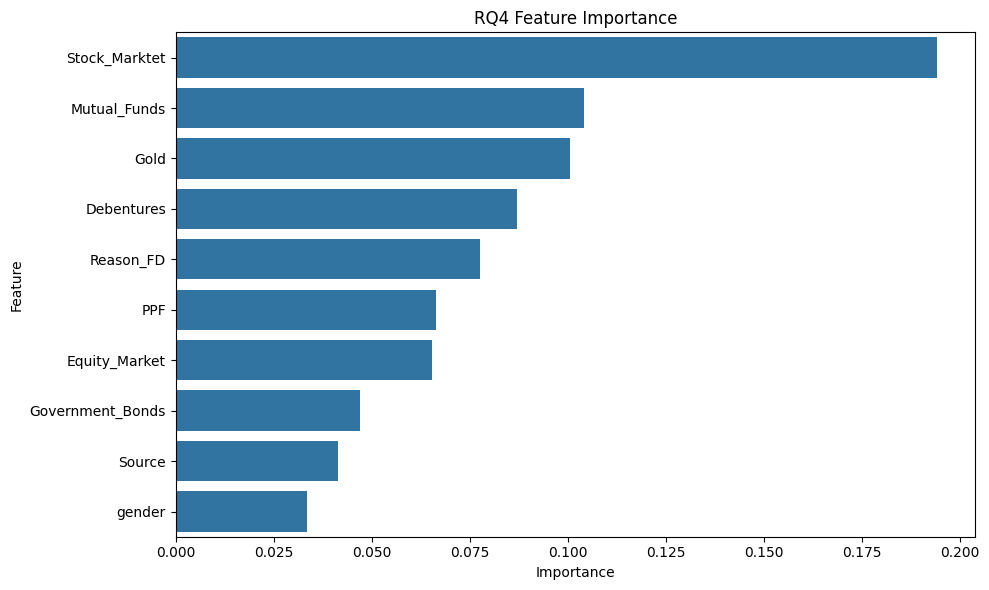

In [7]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("RQ4 Feature Importance")

plt.tight_layout()

plt.savefig("RQ4_feature_importance.pdf")

plt.show()